### Quickstart

Let's first grab some example data from the GitHub repository:

In [1]:
import numpy as np
import requests, io
import matplotlib.pyplot as plt

demo_data_file = requests.get("https://github.com/TutteInstitute/temporal-mapper/raw/docs/docs/data/mapper_demo_data.npy")
X = np.load(io.BytesIO(demo_data_file.content)) 
X = X[np.argsort(X[:,0])]
# shape (n_samples, n_features), the 0th feature is time

We'll use projection to the $x$-axis as our Morse-type function, and a sklearn clusterer to do single-linkage clustering. The `time_index` keyword argument in `fit` determines which axis is the Morse-type function, by default it is -1.
Here's how you fit a TemporalMapper:

In [2]:
import temporalmapper as tm 
from sklearn.cluster import AgglomerativeClustering

## Single-linkage clustering
clusterer = AgglomerativeClustering(
    linkage = "single",
    distance_threshold = 0.1,
    n_clusters = None,
)

mapper = tm.TemporalMapper(
    clusterer = clusterer,
    n_slices = 10
)
mapper.fit(X, time_index=0)

,time,"array([-3.205...hape=(23000,))"
,data,"array([[ 0.78...pe=(23000, 1))"
,clusterer,Agglomerative...clusters=None)
,n_slices,10
,n_neighbors,5
,overlap,0.5
,inclusion_threshold,0.01
,slice_method,'time'
,density_based,True
,kernel,<function squ...x7be8e02fe840>
,kernel_params,None


The output of Mapper is a directed graph; you can access the graph as a NetworkX object via `TemporalMapper.graph`:

In [3]:
mapper.graph

You can also plot the graph using `TemporalMapper.temporal_plot`. We set `layout='semantic'` so our graph will align with our input data.

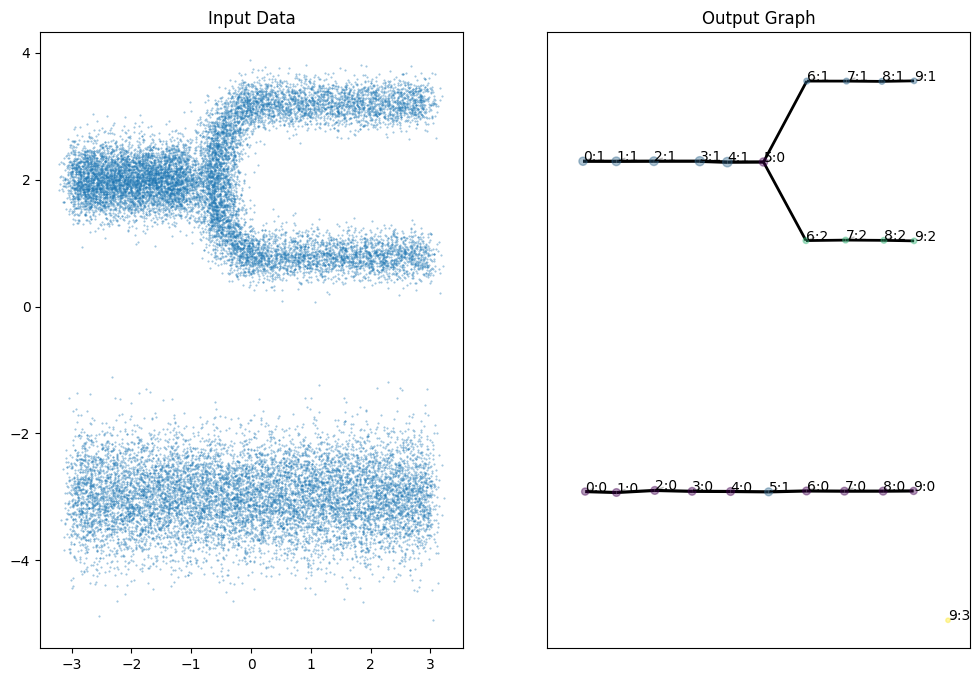

In [4]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,8))
ax1.set_title("Input Data")
ax1.scatter(
    X[:,0], X[:,1], s=0.2, alpha=0.5
)
ax2.set_title("Output Graph")
ax2 = mapper.temporal_plot(ax=ax2, layout='semantic')
plt.show()

If you have Plotly installed, you can also get an interactive HTML/JS plot:

In [5]:
mapper.interactive_temporal_plot(layout='semantic')